# Обучение и сравнение моделей бинарной классификации

Обучаем несколько моделей для выявления аномального поведения кандидата по поведенческим признакам.

1. загрузить синтетический датасет из `ml/data/synthetic_behavior_dataset.csv`;
2. разделить данные на train/test;
3. обучить выбранные модели бинарной классификации;
4. сравнить модели по метрикам;
5. выбрать лучшую модель;
6. сохранить модель и метрики в `ml/artifacts`.

## 1. Импорт библиотек

Используем `pandas` и `numpy` для работы с данными, `scikit-learn` для базовых моделей и метрик, а также бустинговые библиотеки `XGBoost` и `CatBoost`

In [7]:
from pathlib import Path
import json
import time
import warnings

import joblib # для сериализации моделей
import numpy as np
import pandas as pd

from sklearn.base import clone # для создания копий моделей
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier 
from sklearn.impute import SimpleImputer # для обработки пропущенных значений
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,         # метрика точности
    classification_report,  # подробный отчет по классификации
    confusion_matrix,       # матрица ошибок
    f1_score,               # метрика F1
    precision_score,        # метрика точности (precision)
    recall_score,           # метрика полноты (recall)
)
from sklearn.model_selection import train_test_split # для разделения данных на обучающую и тестовую выборки
from sklearn.neighbors import KNeighborsClassifier # алгоритм K-ближайших соседей
from sklearn.pipeline import Pipeline # для создания конвейера обработки данных и обучения модели
from sklearn.preprocessing import StandardScaler # для стандартизации признаков
from sklearn.tree import DecisionTreeClassifier # алгоритм дерева решений
from xgboost import XGBClassifier # градиентный бустинг XGBoost
from catboost import CatBoostClassifier # градиентный бустинг CatBoost

import matplotlib.pyplot as plt # для визуализации данных и результатов

warnings.filterwarnings("ignore")

## 2. Настройки эксперимента

`RANDOM_SEED` фиксирует случайность, чтобы разбиение данных и обучение моделей были воспроизводимыми.

`TEST_SIZE = 0.20` означает, что 20% данных оставляем для финальной проверки качества, а 80% используем для обучения.

In [8]:
RANDOM_SEED = 42
TEST_SIZE = 0.20

DATA_PATH = Path("ml/data/synthetic_behavior_dataset.csv")
ARTIFACTS_DIR = Path("ml/artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

METRICS_PATH = ARTIFACTS_DIR / "anomaly_model_metrics.csv"                    # для сохранения метрик всех моделей
BEST_MODEL_PATH = ARTIFACTS_DIR / "anomaly_best_model.joblib"                 # для сохранения лучшей модели            
METADATA_PATH = ARTIFACTS_DIR / "anomaly_model_metadata.json"                 # для сохранения метаданных лучшей модели (гиперпараметры, метрики и т.д.)
CONFUSION_MATRIX_PATH = ARTIFACTS_DIR / "confusion_matrix_best_model.png"     # для сохранения графика матрицы ошибок лучшей модели
FEATURE_IMPORTANCE_PATH = ARTIFACTS_DIR / "feature_importance_best_model.png" # для сохранения графика важности признаков лучшей модели

print("Датасет:", DATA_PATH)
print("Папка артефактов:", ARTIFACTS_DIR)

Датасет: ml/data/synthetic_behavior_dataset.csv
Папка артефактов: ml/artifacts


## 3. Загрузка датасета

Загружаем CSV, который был сформирован в предыдущем notebook-е генерации поведенческих признаков.

In [9]:
dataset = pd.read_csv(DATA_PATH)

print("Размер датасета:", dataset.shape)
display(dataset.head())

print("Распределение классов:")
display(dataset["is_anomaly"].value_counts().rename("count"))
display(dataset["is_anomaly"].value_counts(normalize=True).rename("share").round(3))

Размер датасета: (5000, 14)


,response_time_sec,tab_switch_count,total_hidden_time_sec,hidden_time_ratio,paste_count,pasted_chars_total,paste_ratio,input_event_count,delete_count,max_pause_sec,max_input_burst_chars,copy_count,answer_length_chars,is_anomaly
0,232.753,0,0.000,0.000000,0,0,0.0,56,10,10.504,44,0,617,0
1,259.177,1,26.370,0.101745,0,0,0.0,50,3,5.935,16,0,276,0
2,213.754,0,0.000,0.000000,0,0,0.0,42,6,24.093,58,0,471,0
3,637.918,1,48.717,0.076369,0,0,0.0,250,12,6.551,27,0,1371,0
4,297.998,0,0.000,0.000000,0,0,0.0,68,6,6.620,38,0,632,0


Распределение классов:


is_anomaly
0    3500
1    1500
Name: count, dtype: int64

is_anomaly
0    0.7
1    0.3
Name: share, dtype: float64

## 4. Проверка признаков

Здесь явно задаем список признаков, которые модель имеет право использовать.

Этот список совпадает с:

- таблицей `behavior_features` в PostgreSQL;
- классом `BehaviorMetrics` в backend;

Не используем `anomaly_probability` и `anomaly_risk`, потому что это результат модели, а не входные данные.

In [10]:
FEATURE_COLUMNS = [
    "response_time_sec",
    "tab_switch_count",
    "total_hidden_time_sec",
    "hidden_time_ratio",
    "paste_count",
    "pasted_chars_total",
    "paste_ratio",
    "input_event_count",
    "delete_count",
    "max_pause_sec",
    "max_input_burst_chars",
    "copy_count",
    "answer_length_chars",
]

TARGET_COLUMN = "is_anomaly"
EXPECTED_COLUMNS = FEATURE_COLUMNS + [TARGET_COLUMN]

# Проверяем, что в датасете есть все необходимые колонки и нет лишних
missing_columns = [column for column in EXPECTED_COLUMNS if column not in dataset.columns]
# Проверяем, что в датасете нет пропусков в ожидаемых колонках
extra_columns = [column for column in dataset.columns if column not in EXPECTED_COLUMNS]

if missing_columns:
    raise ValueError(f"В датасете не хватает колонок: {missing_columns}")
if extra_columns:
    raise ValueError(f"В датасете есть лишние колонки: {extra_columns}")
if dataset[EXPECTED_COLUMNS].isna().any().any():
    raise ValueError("В датасете есть пропуски.")

print("Проверка структуры датасета пройдена.")
print("Количество входных признаков:", len(FEATURE_COLUMNS))

Проверка структуры датасета пройдена.
Количество входных признаков: 13


## 5. Разделение на признаки и целевую переменную

`X` содержит только поведенческие признаки.

`y` содержит целевую переменную `is_anomaly`:

- `0` — нормальное поведение;
- `1` — аномальное поведение.

In [11]:
X = dataset[FEATURE_COLUMNS]
y = dataset[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y, # сохраняем пропорцию классов в обучающей и тестовой выборках
)

print("Train:", X_train.shape, y_train.value_counts().sort_index().to_dict())
print("Test:", X_test.shape, y_test.value_counts().sort_index().to_dict())

Train: (4000, 13) {0: 2800, 1: 1200}
Test: (1000, 13) {0: 700, 1: 300}


## 6. Подготовка моделей

Для сравнения оставляем семь моделей:

- `LogisticRegression` — простой и интерпретируемый baseline;
- `KNeighborsClassifier` — метод ближайших соседей;
- `DecisionTree` — одиночное дерево решений;
- `RandomForest` — ансамбль деревьев;
- `GradientBoosting` — бустинг из sklearn;
- `XGBoost` — популярный градиентный бустинг для табличных данных;
- `CatBoost` — градиентный бустинг, часто используемый для табличных задач.

Для моделей, чувствительных к масштабу признаков, используется `StandardScaler`. Для деревьев и бустингов стандартизация не требуется.

In [12]:
def scaled_model(model):
    """Создает pipeline: заполнение пропусков, стандартизация, модель."""

    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")), # заполняем пропуски медианой так как многие модели не могут работать с пропусками, а медиана устойчива к выбросам
            ("scaler", StandardScaler()), # стандартизация признаков
            ("model", model), # модель, переданная в аргументе
        ]
    )


def tree_model(model):
    """Создает pipeline для деревьев и бустингов без стандартизации."""

    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")), # заполняем пропуски медианой 
            ("model", model), # модель, переданная в аргументе
        ]
    )


models = {
    "LogisticRegression": scaled_model(
        LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED) 
    ),
    "KNeighborsClassifier": scaled_model(KNeighborsClassifier(n_neighbors=7)),
    "DecisionTree": tree_model(
        DecisionTreeClassifier(max_depth=None, class_weight="balanced", random_state=RANDOM_SEED)
    ),
    "RandomForest": tree_model(
        RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_SEED, n_jobs=-1)
    ),
    "GradientBoosting": tree_model(
        GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, random_state=RANDOM_SEED)
    ),
    "XGBoost": tree_model(
        XGBClassifier(
            n_estimators=300, # количество деревьев
            max_depth=4, # максимальная глубина дерева
            learning_rate=0.05, # скорость обучения
            subsample=0.9, # доля объектов для обучения каждого дерева
            colsample_bytree=0.9, # доля признаков для обучения каждого дерева
            eval_metric="logloss", # метрика для оценки качества модели во время обучения
            random_state=RANDOM_SEED,
            n_jobs=-1, # использовать все ядра процессора для обучения
        )
    ),
    "CatBoost": tree_model(
        CatBoostClassifier(
            iterations=300, # количество деревьев
            depth=5, # максимальная глубина дерева
            learning_rate=0.05, # скорость обучения
            loss_function="Logloss", # функция потерь для бинарной классификации
            eval_metric="Logloss", # метрика качества во время обучения
            random_seed=RANDOM_SEED,
            verbose=False, # отключаем вывод процесса обучения в консоль
        )
    ),
}

print("Количество моделей для сравнения:", len(models))
print(*models.keys(), sep="\n")

Количество моделей для сравнения: 7
LogisticRegression
KNeighborsClassifier
DecisionTree
RandomForest
GradientBoosting
XGBoost
CatBoost


## 7. Обучение и оценка моделей

Для каждой модели считаем:

- `accuracy` — общая доля правильных ответов;
- `precision` — насколько редко модель ошибочно помечает нормальное поведение как аномальное;
- `recall` — насколько хорошо модель находит реальные аномалии;
- `f1` — баланс precision и recall.

В качестве основного критерия выбора используем `F1`, затем `precision`, `recall` и `accuracy`.

Если несколько моделей показывают одинаковые или почти одинаковые метрики, выбираем более простую и интерпретируемую модель. 

In [ ]:
def get_positive_probability(model, X_data):
    """Возвращает вероятность класса 1, если модель умеет ее считать."""

    # Все выбранные модели поддерживают predict_proba.
    # predict_proba возвращает две колонки:
    # [:, 0] - вероятность класса 0, то есть нормального поведения;
    # [:, 1] - вероятность класса 1, то есть аномального поведения.
    return model.predict_proba(X_data)[:, 1]


results = [] # список для хранения метрик всех моделей
fitted_models = {} # словарь для хранения обученных моделей, чтобы потом сохранить лучшую модель на диск

# Обучаем каждую модель, делаем предсказания и сохраняем метрики
for model_name, model in models.items():
    print(f"Обучение: {model_name}")
    start_time = time.perf_counter() # фиксируем время начала обучения

    # clone создает независимую копию модели с теми же гиперпараметрами, чтобы избежать нежелательных побочных эффектов при обучении разных моделей в цикле
    fitted_model = clone(model)
    # обучаем модель на обучающей выборке
    fitted_model.fit(X_train, y_train)

    # делаем предсказания классов на тестовой выборке
    y_pred = fitted_model.predict(X_test)

    # рассчитываем время обучения модели
    elapsed_sec = round(time.perf_counter() - start_time, 3)

    # сохраняем метрики модели в список results для последующего сравнения
    results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "fit_time_sec": elapsed_sec,
        }
    )

    # сохраняем обученную модель в словарь для последующего сохранения лучшей модели на диск
    fitted_models[model_name] = fitted_model

# Если метрики равны или почти равны, используем дополнительный критерий простоты.
# Меньшее значение complexity_rank означает более простую и интерпретируемую модель.
MODEL_COMPLEXITY_RANK = {
    "LogisticRegression": 1,
    "DecisionTree": 2,
    "KNeighborsClassifier": 3,
    "RandomForest": 4,
    "GradientBoosting": 5,
    "XGBoost": 6,
    "CatBoost": 7,
}

# Создаем DataFrame из результатов и сортируем модели по метрикам и сложности
metrics = pd.DataFrame(results)
# Добавляем колонку с рангом сложности модели для использования в качестве дополнительного критерия при сравнении моделей с близкими метриками.
metrics["complexity_rank"] = metrics["model"].map(MODEL_COMPLEXITY_RANK).fillna(50).astype(int)
# Сортируем модели по метрикам в порядке убывания, а при равенстве метрик - по сложности и времени обучения в порядке возрастания.
metrics = metrics.sort_values(
    by=["f1", "precision", "recall", "accuracy", "complexity_rank", "fit_time_sec"],
    ascending=[False, False, False, False, True, True],
).reset_index(drop=True)

# Округляем метрики до 4 знаков после запятой для более компактного отображения
metrics_rounded = metrics.copy()
for column in ["accuracy", "precision", "recall", "f1", "fit_time_sec"]:
    metrics_rounded[column] = metrics_rounded[column].round(4)

# Отображаем итоговую таблицу с метриками всех моделей, отсортированную по качеству и сложности
display(metrics_rounded)

## 8. Выбор лучшей модели

Лучшая модель выбирается по таблице метрик. Основной критерий — `F1`, поскольку он учитывает баланс precision и recall.

Если несколько моделей показывают одинаковый результат, приоритет получает более простая и интерпретируемая модель. В рамках данной задачи это разумно: если логистическая регрессия показывает качество не хуже сложных бустингов, ее проще объяснить, быстрее обучать и проще поддерживать в backend-е.

In [ ]:
best_row = metrics.iloc[0] # выбираем первую строку (лучшую модель)
best_model_name = best_row["model"] # извлекаем название лучшей модели из колонки "model" в первой строке отсортированного DataFrame
best_model = fitted_models[best_model_name] # извлекаем обученную модель из словаря fitted_models по названию лучшей модели

print("Лучшая модель:", best_model_name)
print(best_row.round(4).to_string()) # выводим метрики лучшей модели, округленные до 4 знаков после запятой, в виде строки для компактного отображения

best_pred = best_model.predict(X_test) # делаем предсказания классов лучшей модели на тестовой выборке

print("\nClassification report для лучшей модели:")
print(classification_report(y_test, best_pred, target_names=["normal", "anomaly"], zero_division=0))

## 9. Матрица ошибок лучшей модели

Матрица ошибок показывает четыре случая:

- нормальное поведение распознано как нормальное;
- нормальное поведение ошибочно распознано как аномальное;
- аномальное поведение ошибочно пропущено;
- аномальное поведение распознано как аномальное.

,pred_normal,pred_anomaly
true_normal,700,0
true_anomaly,0,300


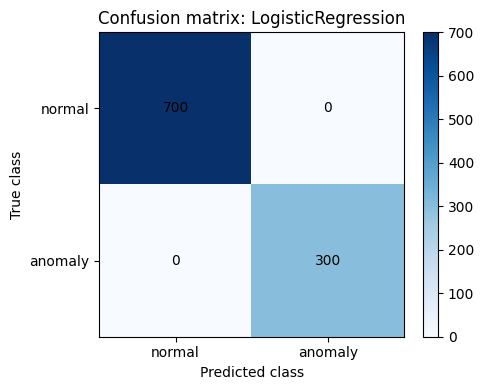

Матрица ошибок сохранена: ml/artifacts/confusion_matrix_best_model.png


In [15]:
cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(
    cm,
    index=["true_normal", "true_anomaly"],
    columns=["pred_normal", "pred_anomaly"],
)
display(cm_df)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_title(f"Confusion matrix: {best_model_name}")
ax.set_xlabel("Predicted class")
ax.set_ylabel("True class")
ax.set_xticks([0, 1], labels=["normal", "anomaly"])
ax.set_yticks([0, 1], labels=["normal", "anomaly"])

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center")

fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=160)
plt.show()

print("Матрица ошибок сохранена:", CONFUSION_MATRIX_PATH)

## 10. Важность признаков лучшей модели

,feature,importance
0,paste_ratio,3.1232
1,tab_switch_count,1.9932
2,hidden_time_ratio,1.9605
3,total_hidden_time_sec,1.2923
4,max_input_burst_chars,1.2390
5,pasted_chars_total,1.2241
6,max_pause_sec,1.2180
7,copy_count,1.1042
8,input_event_count,1.0537
9,paste_count,0.7836


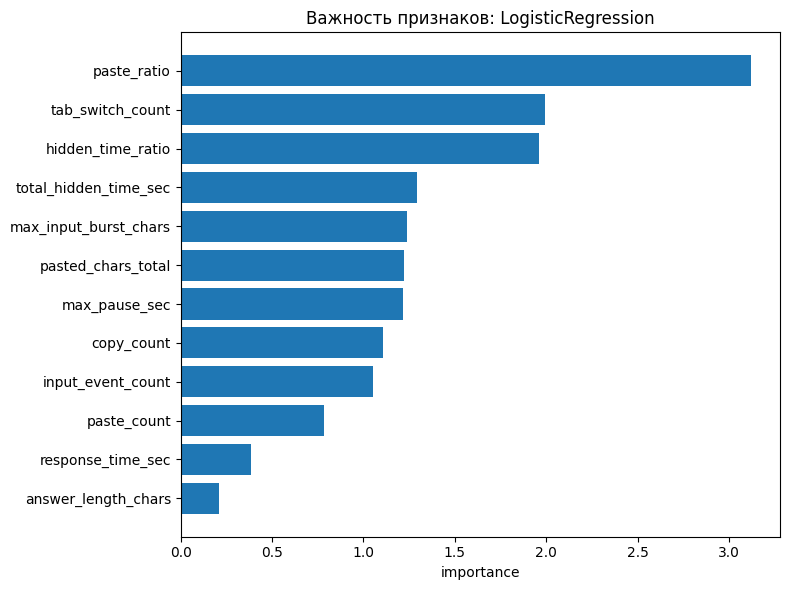

Важность признаков сохранена: ml/artifacts/feature_importance_best_model.png


In [17]:
def unwrap_model(model):
    """Если модель находится внутри Pipeline, достаем последний шаг."""

    if hasattr(model, "named_steps") and "model" in model.named_steps:
        return model.named_steps["model"]
    return model


def get_feature_importance(model, feature_columns):
    """Возвращает таблицу важности признаков, если модель позволяет ее получить."""

    inner_model = unwrap_model(model)

    if hasattr(inner_model, "feature_importances_"):
        importance = inner_model.feature_importances_
    elif hasattr(inner_model, "coef_"):
        importance = np.abs(inner_model.coef_).ravel()
    else:
        return None

    return pd.DataFrame(
        {
            "feature": feature_columns,
            "importance": importance,
        }
    ).sort_values("importance", ascending=False).reset_index(drop=True)


feature_importance = get_feature_importance(best_model, FEATURE_COLUMNS)

if feature_importance is None:
    print(f"Для модели {best_model_name} нельзя напрямую получить важность признаков.")
else:
    display(feature_importance.round(4))

    top_features = feature_importance.head(12).sort_values("importance")
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_features["feature"], top_features["importance"])
    ax.set_title(f"Важность признаков: {best_model_name}")
    ax.set_xlabel("importance")
    fig.tight_layout()
    fig.savefig(FEATURE_IMPORTANCE_PATH, dpi=160)
    plt.show()

    print("Важность признаков сохранена:", FEATURE_IMPORTANCE_PATH)

## 11. Сохранение лучшей модели и метрик

Сохраняем:

- лучшую модель в `anomaly_best_model.joblib`;
- таблицу метрик в `anomaly_model_metrics.csv`;
- metadata JSON со списком признаков и выбранной моделью.

Эти файлы понадобятся backend-у для подключения обученной модели.

In [ ]:
metrics_rounded.to_csv(METRICS_PATH, index=False)
joblib.dump(best_model, BEST_MODEL_PATH)

metadata = {
    "best_model_name": best_model_name,
    "target_column": TARGET_COLUMN,
    "feature_columns": FEATURE_COLUMNS,
    "test_size": TEST_SIZE,
    "random_seed": RANDOM_SEED,
    "selection_rule": "sort by f1, precision, recall, accuracy; if metrics are tied, prefer simpler model by complexity_rank",
    "best_metrics": {
        key: float(best_row[key]) if key != "model" else str(best_row[key])
        for key in best_row.index
    },
}

METADATA_PATH.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")

print("Метрики сохранены:", METRICS_PATH)
print("Лучшая модель сохранена:", BEST_MODEL_PATH)
print("Metadata сохранена:", METADATA_PATH)

## 12. Проверка загрузки сохраненной модели

Финальная проверка: загружаем модель из файла и убеждаемся, что она может вернуть вероятность аномального поведения для тестовых строк.

In [19]:
loaded_model = joblib.load(BEST_MODEL_PATH)
loaded_probability = get_positive_probability(loaded_model, X_test.head(5))

pd.DataFrame(
    {
        "true_is_anomaly": y_test.head(5).to_list(),
        "predicted_probability": np.round(loaded_probability, 4),
    }
)

,true_is_anomaly,predicted_probability
0,0,0.0008
1,1,0.9997
2,0,0.0014
3,0,0.0053
4,0,0.0020
